In [1]:
#0
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

student_name = "Ayisha Claire Angeles"
student_id = "20254496"  # Replace with your actual ID

id_num = int(student_id[-3:])

color1 = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) % 256:02x}"
color2 = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4) % 256:02x}"

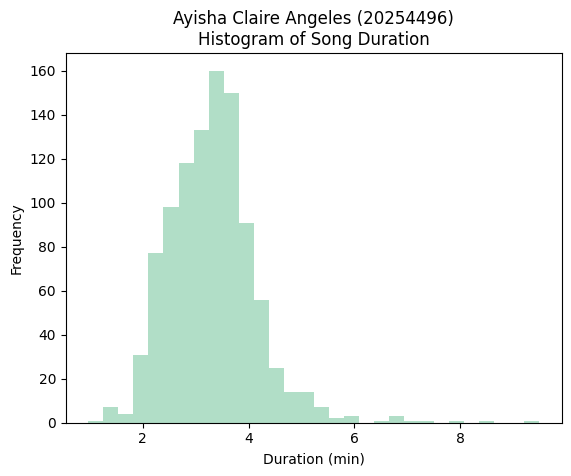

In [2]:
#1
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("spotify_top_1000_tracks.csv")
df['duration_min'].plot(kind='hist', bins=30, color=color1, alpha=0.7) 
plt.title(f"{student_name} ({student_id})\nHistogram of Song Duration") 
plt.xlabel('Duration (min)') 
plt.ylabel('Frequency') 
plt.show() 

In [3]:
print(df.columns)

Index(['track_name', 'artist', 'album', 'release_date', 'popularity',
       'spotify_url', 'id', 'duration_min'],
      dtype='str')


C:\Users\Ayisha Claire\AppData\Local\Temp\ipykernel_26024\2418886398.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm')


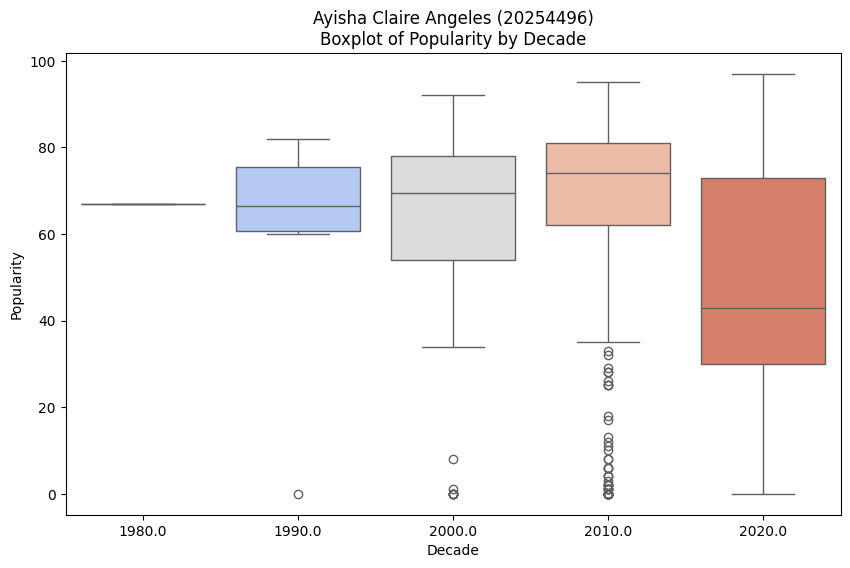

In [4]:
#2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df.columns = df.columns.str.strip()

# convert to datetime safely (handles BOTH "2002" and "2018-02-09")
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

# extract year safely
df['year'] = df['release_date'].dt.year

# drop rows where year failed (optional but recommended)
df = df.dropna(subset=['year'])

# create decade
df['decade'] = (df['year'] // 10) * 10

# plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm')

plt.title(f"{student_name} ({student_id})\nBoxplot of Popularity by Decade")
plt.xlabel("Decade")
plt.ylabel("Popularity")

plt.show()

C:\Users\Ayisha Claire\AppData\Local\Temp\ipykernel_26024\593441324.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


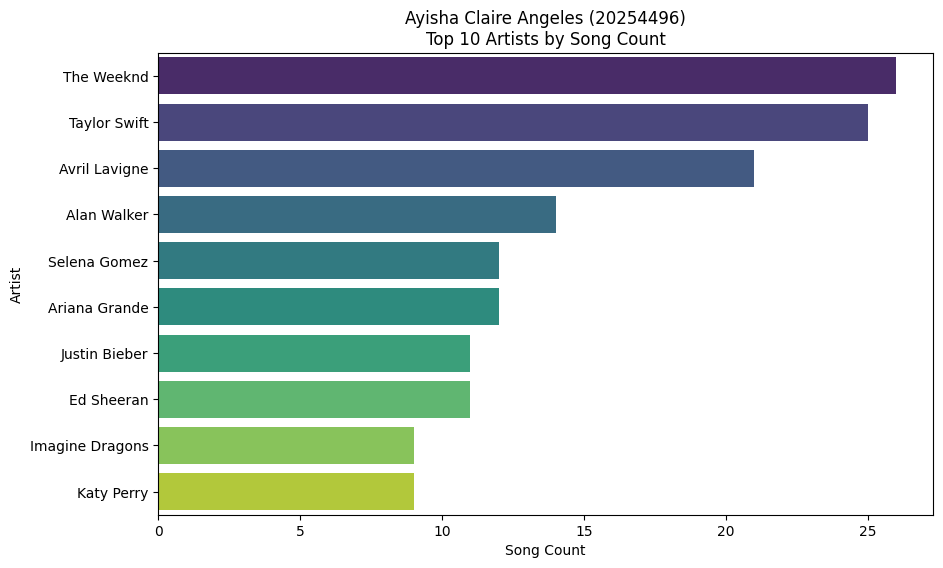

In [5]:
#3
import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 artists
top_artists = df['artist'].value_counts().head(10).index

plt.figure(figsize=(10, 6))

sns.countplot(
    y='artist',
    data=df,
    order=top_artists,
    palette='viridis'
)

plt.title(f"{student_name} ({student_id})\nTop 10 Artists by Song Count")
plt.xlabel("Song Count")
plt.ylabel("Artist")

plt.show()

In [6]:
import pandas as pd

df = pd.read_csv("spotify_top_1000_tracks.csv")  # replace with actual filename

In [7]:
df.columns = df.columns.str.strip()

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year
df['decade'] = (df['year'] // 10) * 10

C:\Users\Ayisha Claire\AppData\Local\Temp\ipykernel_26024\3253962917.py:24: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


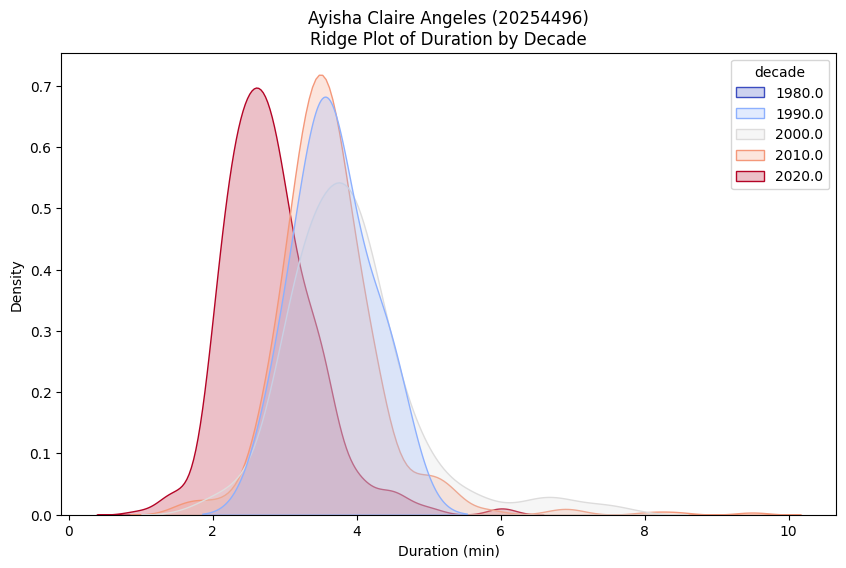

In [8]:
#4
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# reload if needed
df = pd.read_csv("spotify_top_1000_tracks.csv")

# clean columns
df.columns = df.columns.str.strip()

# create decade
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year
df['decade'] = (df['year'] // 10) * 10

# student info (IMPORTANT)
student_name = "Ayisha Claire Angeles"
student_id = "20254496"

# plot
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df,
    x='duration_min',
    hue='decade',
    fill=True,
    common_norm=False,
    palette='coolwarm'
)

plt.title(f"{student_name} ({student_id})\nRidge Plot of Duration by Decade")
plt.xlabel("Duration (min)")
plt.ylabel("Density")

plt.show()

In [9]:
student_name = "Ayisha Claire Angeles"
student_id = "20254496"

id_num = int(student_id[-3:])
color1 = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) % 256:02x}"

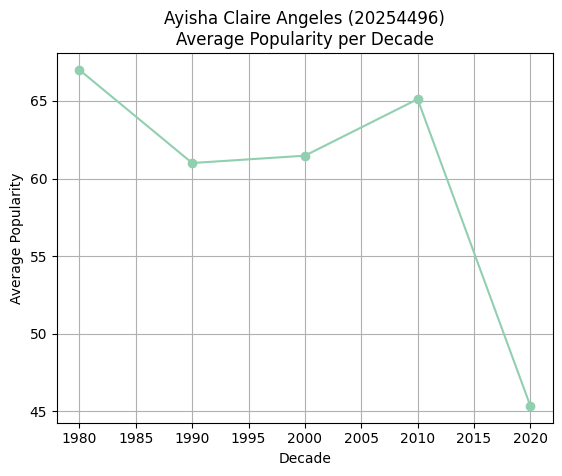

In [10]:
#5
import matplotlib.pyplot as plt

# group and compute mean
avg_pop = df.groupby('decade')['popularity'].mean()

# plot
avg_pop.plot(kind='line', color=color1, marker='o')

plt.title(f"{student_name} ({student_id})\nAverage Popularity per Decade")
plt.xlabel('Decade')
plt.ylabel('Average Popularity')
plt.grid(True)

plt.show()

In [11]:
student_name = "Ayisha Claire Angeles"
student_id = "20254496"

id_num = int(student_id[-3:])

color1 = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) % 256:02x}"
color2 = f"#{(id_num * 5) % 256:02x}{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}"

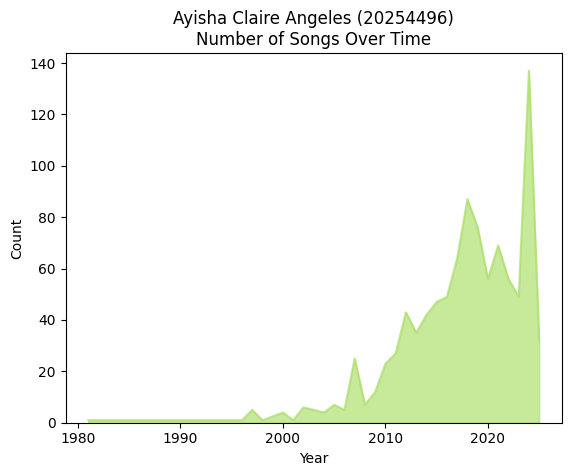

In [12]:
#6
import pandas as pd
import matplotlib.pyplot as plt

# ensure date is parsed
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

# count songs per year
count_by_year = df['release_year'].value_counts().sort_index()

# plot
count_by_year.plot(kind='area', color=color2, alpha=0.7)

plt.title(f"{student_name} ({student_id})\nNumber of Songs Over Time")
plt.xlabel('Year')
plt.ylabel('Count')

plt.show()

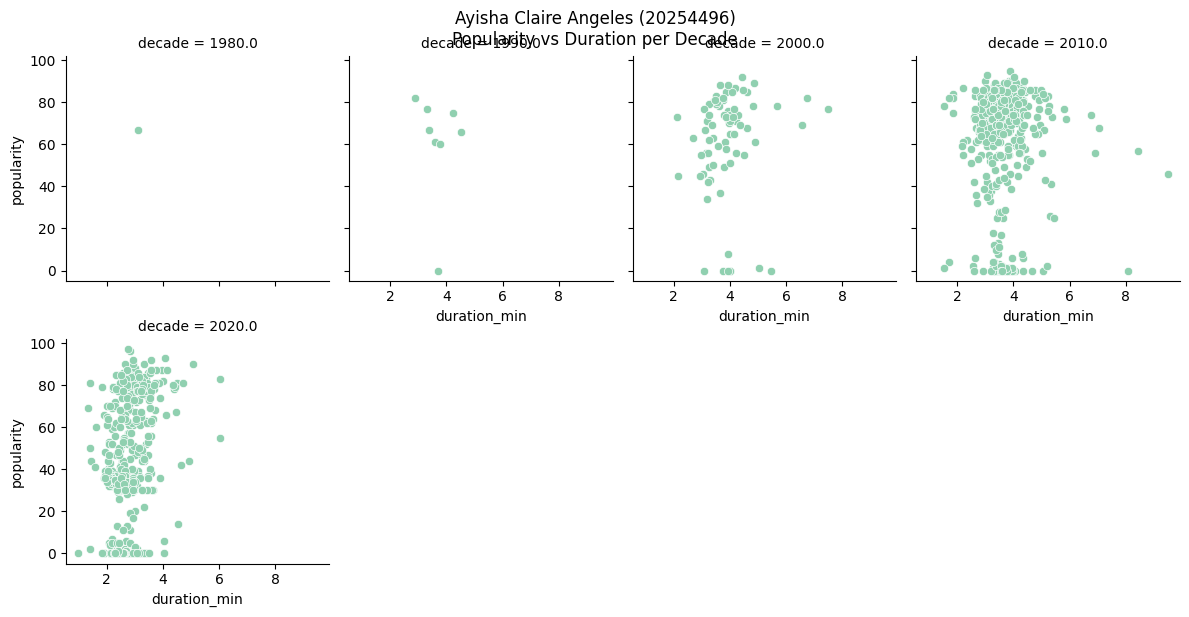

In [13]:
#7
import seaborn as sns
import matplotlib.pyplot as plt

# safety check (optional but recommended)
df.columns = df.columns.str.strip()

# FacetGrid plot
g = sns.FacetGrid(df, col='decade', col_wrap=4, height=3)

g.map_dataframe(
    sns.scatterplot,
    x='duration_min',
    y='popularity',
    color=color1
)

g.fig.suptitle(
    f"{student_name} ({student_id})\nPopularity vs Duration per Decade",
    y=1.02
)

plt.show()

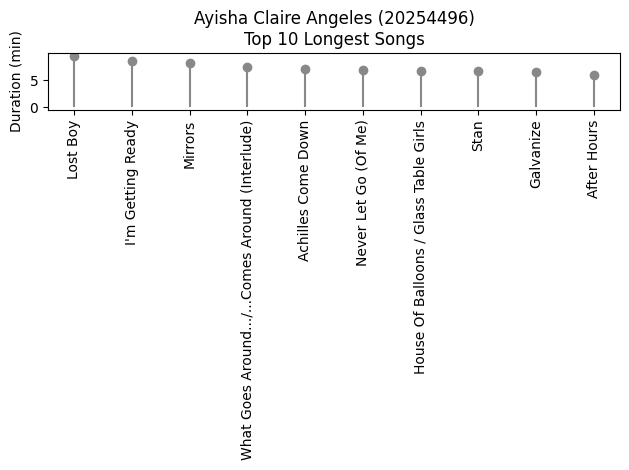

In [14]:
#8
longest = df.nlargest(10, 'duration_min') 
plt.stem(longest['track_name'], longest['duration_min'], 
linefmt='#888888', markerfmt='o', basefmt=" ") 
plt.xticks(rotation=90) 
plt.title(f"{student_name} ({student_id})\nTop 10 Longest Songs") 
plt.ylabel('Duration (min)') 
plt.tight_layout() 
plt.show() 

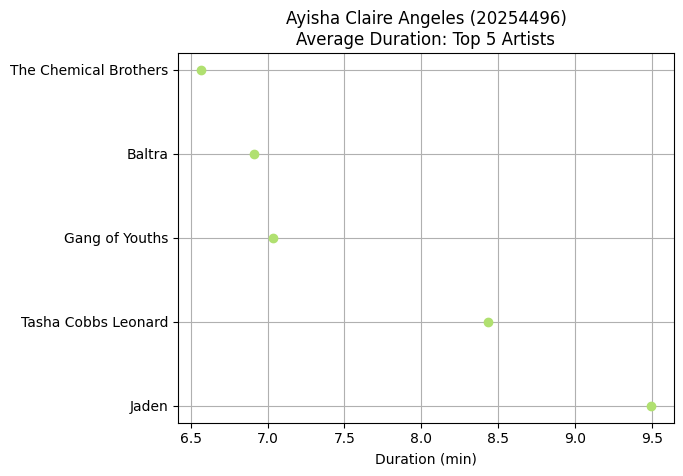

In [15]:
#9
avg_duration = df.groupby('artist')['duration_min'].mean().nlargest(5) 
plt.plot(avg_duration.values, avg_duration.index, 'o', color=color2) 
plt.title(f"{student_name} ({student_id})\nAverage Duration: Top 5 Artists") 
plt.xlabel('Duration (min)') 
plt.grid(True) 
plt.show() 

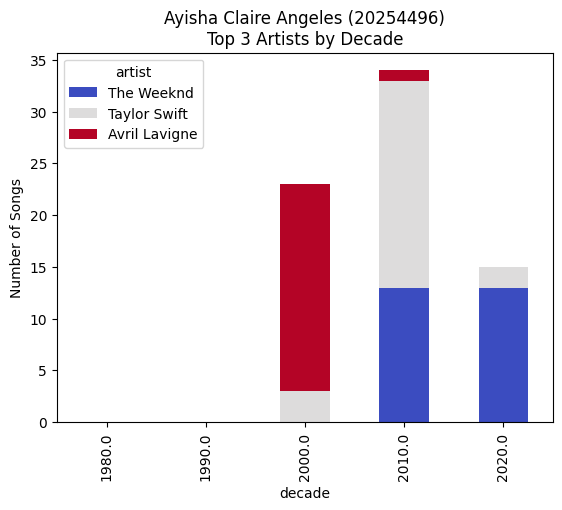

In [16]:
#10
crosstab = pd.crosstab(df['decade'], df['artist']) 
top3 = df['artist'].value_counts().head(3).index 
crosstab[top3].plot(kind='bar', stacked=True, colormap='coolwarm') 
plt.title(f"{student_name} ({student_id})\nTop 3 Artists by Decade") 
plt.ylabel('Number of Songs') 
plt.show() 

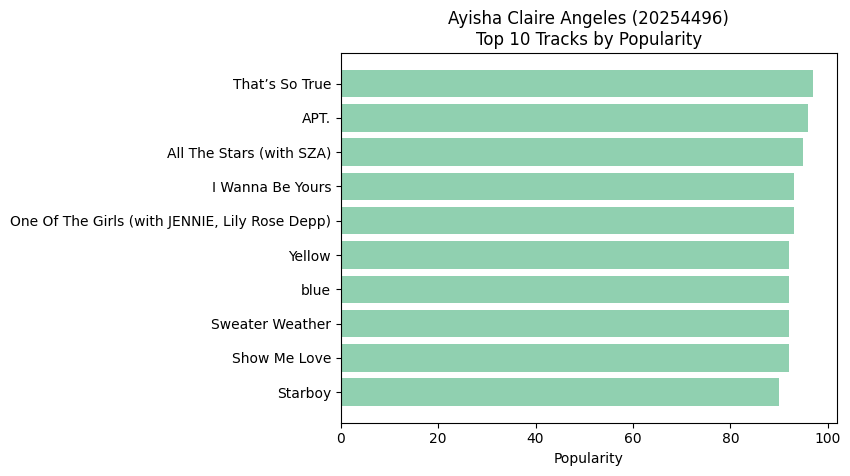

In [17]:
#11
top_tracks = df.nlargest(10, 'popularity') 
plt.barh(top_tracks['track_name'], top_tracks['popularity'], color=color1) 
plt.xlabel('Popularity') 
plt.title(f"{student_name} ({student_id})\nTop 10 Tracks by Popularity") 
plt.gca().invert_yaxis() 
plt.show() 

C:\Users\Ayisha Claire\AppData\Local\Temp\ipykernel_26024\107862491.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist',
C:\Users\Ayisha Claire\AppData\Local\Temp\ipykernel_26024\107862491.py:3: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist',


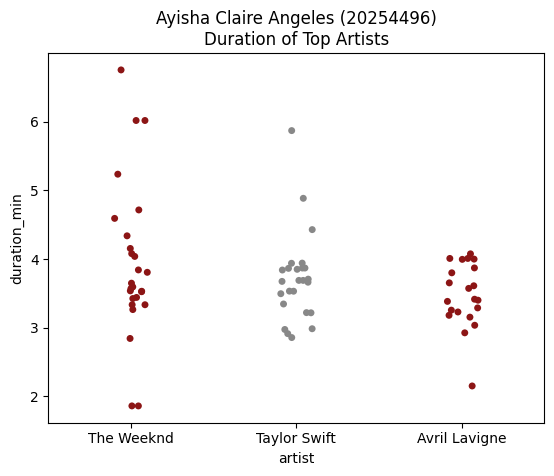

In [18]:
#12
top_artists = df['artist'].value_counts().head(3).index 
sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist', 
y='duration_min', palette=['#8C1515', '#888888']) 
plt.title(f"{student_name} ({student_id})\nDuration of Top Artists") 
plt.show()

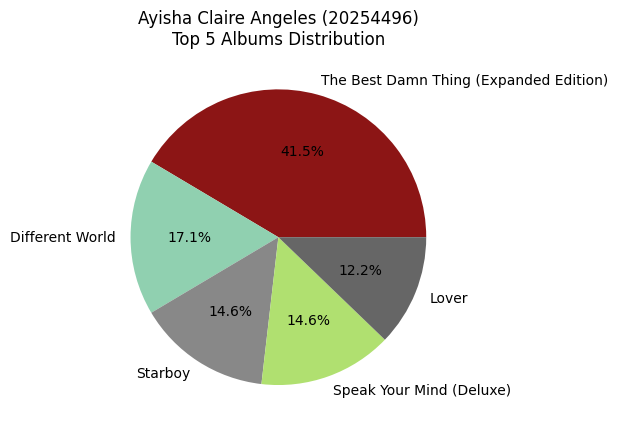

In [19]:
#13
top_albums = df['album'].value_counts().head(5) 
colors = ['#8C1515', color1, '#888888', color2, '#666666'] 
plt.pie(top_albums, labels=top_albums.index, autopct='%1.1f%%', 
colors=colors) 
plt.title(f"{student_name} ({student_id})\nTop 5 Albums Distribution") 
plt.show() 

In [20]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import pandas as pd

df = pd.read_csv("spotify_top_1000_tracks.csv")  # replace with actual filename

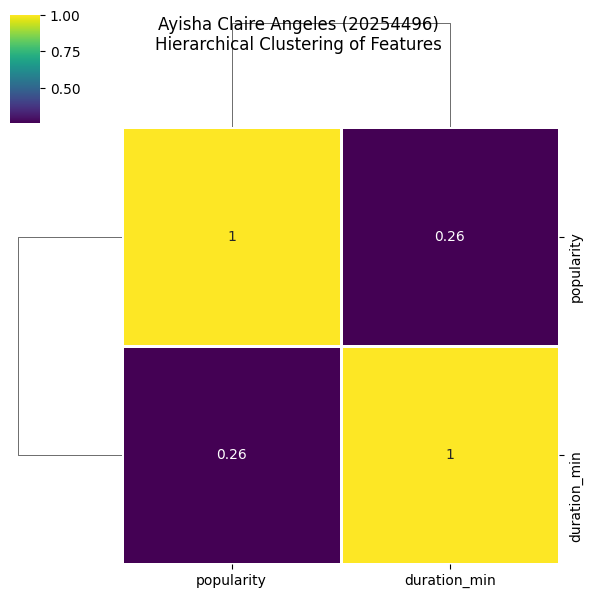

In [22]:
#14
numerical_cols = ['popularity', 'duration_min'] 
df_numeric = df[numerical_cols].dropna() 
sns.clustermap(df_numeric.corr(), annot=True, cmap='viridis', 
linewidths=.75, figsize=(6, 6)) 
plt.suptitle(f"{student_name} ({student_id})\nHierarchical Clustering of Features") 
plt.show()

In [23]:
import pandas as pd

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year

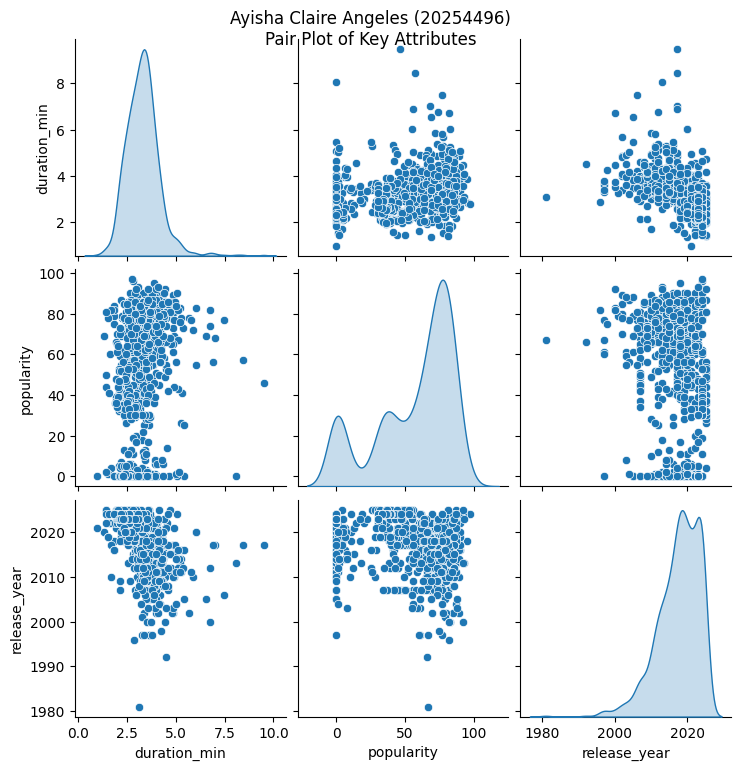

In [24]:
#15
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['duration_min', 'popularity', 'release_year']

sns.pairplot(
    df[cols].dropna(),
    diag_kind='kde'
)

plt.suptitle(f"{student_name} ({student_id})\nPair Plot of Key Attributes", y=1.02)

plt.show()

In [25]:
import pandas as pd

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year

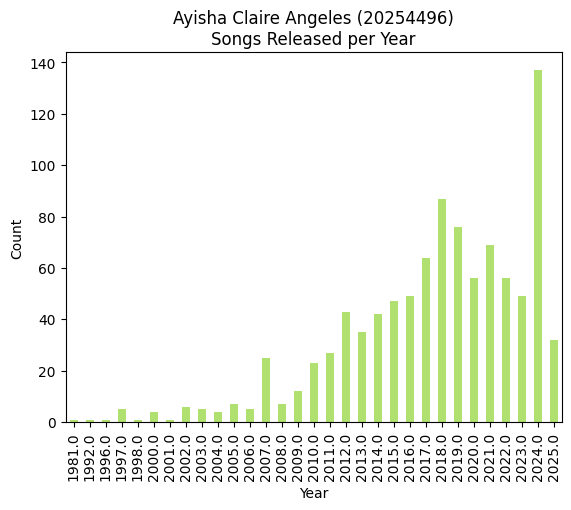

In [26]:
#16
df['release_year'].value_counts().sort_index().plot(
    kind='bar',
    color=color2
)

plt.title(f"{student_name} ({student_id})\nSongs Released per Year")
plt.ylabel('Count')
plt.xlabel('Year')
plt.show()

C:\Users\Ayisha Claire\AppData\Local\Temp\ipykernel_26024\2057180512.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=df.head(50), x='artist', y='popularity',


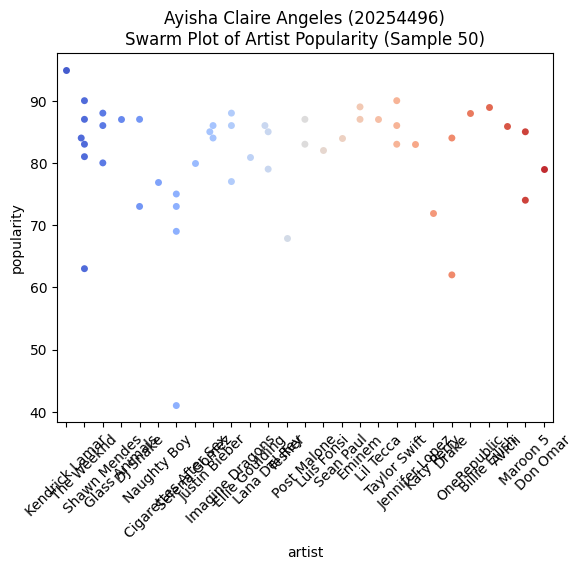

In [27]:
#17
sns.swarmplot(data=df.head(50), x='artist', y='popularity', 
palette='coolwarm') 
plt.title(f"{student_name} ({student_id})\nSwarm Plot of Artist Popularity (Sample 50)") 
plt.xticks(rotation=45) 
plt.show()

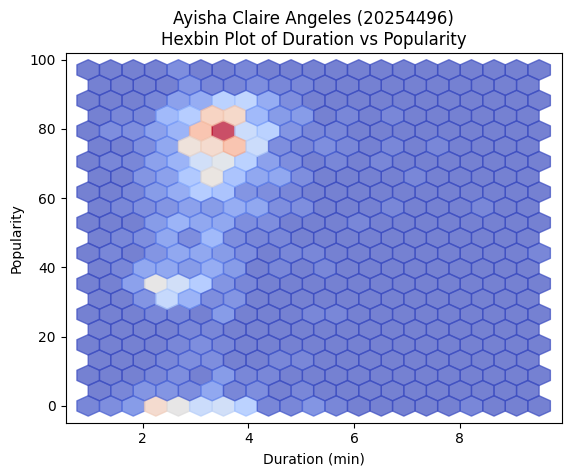

In [28]:
#18
plt.hexbin(df['duration_min'], df['popularity'], gridsize=20, 
cmap='coolwarm', alpha=0.7) 
plt.xlabel('Duration (min)') 
plt.ylabel('Popularity') 
plt.title(f"{student_name} ({student_id})\nHexbin Plot of Duration vs Popularity")
 
plt.show() 

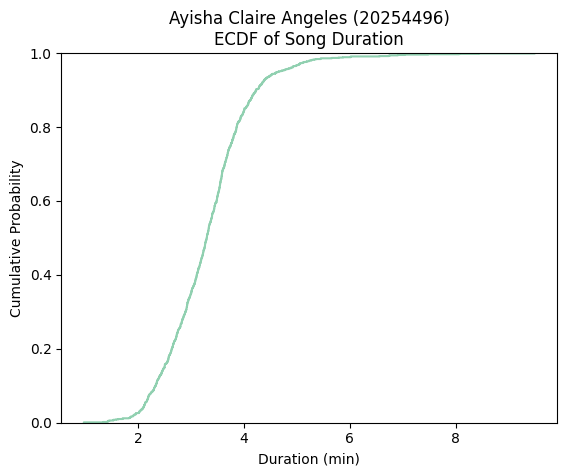

In [29]:
#19
sns.ecdfplot(data=df, x='duration_min', color=color1) 
plt.title(f"{student_name} ({student_id})\nECDF of Song Duration") 
plt.xlabel('Duration (min)') 
plt.ylabel('Cumulative Probability') 
plt.show() 

In [30]:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year
df['decade'] = (df['release_year'] // 10) * 10

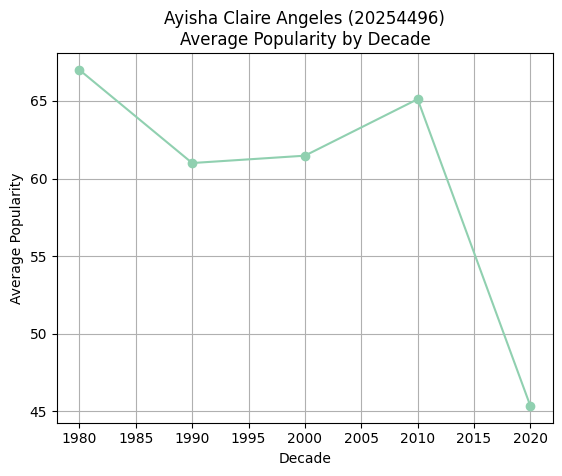

In [31]:
#20
avg_pop = df.groupby('decade')['popularity'].mean()

avg_pop.plot(kind='line', color=color1, marker='o')

plt.title(f"{student_name} ({student_id})\nAverage Popularity by Decade")
plt.xlabel('Decade')
plt.ylabel('Average Popularity')
plt.grid(True)

plt.show()